In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import json
from collections import defaultdict


## Dataset Path

In [ ]:
#
adapt=2
test_ds_b4=False
if test_ds_b4:
    identifier=f"testing_dsb4_adaptable{adapt}" if adapt > 0 else "testing_dsb4"
else:
    identifier=f"30000_1000_100_adaptable{adapt}" if adapt > 0 else "30000_1000_100"
    # identifier="1000_200_median"
parent_dir=os.path.join(os.getcwd(),os.pardir,os.pardir)
dataset_path=os.path.join(parent_dir,"extract_Nripples","train_pedro","dataset_up_down",identifier)
datasets=os.listdir(dataset_path)
if "config.json" in datasets:
    datasets.remove("config.json")
print(f"Datasets found: {datasets}")    
print("Loaded from:",identifier)

FileNotFoundError: [WinError 3] O sistema não conseguiu localizar o caminho especificado: 'c:\\Users\\Pc\\Documents\\Tese\\LAVA_SNN_ripples\\snnTorch\\eval\\..\\..\\extract_Nripples\\train_pedro\\dataset_up_down\\30000_1000_100_adaptable2'

In [743]:
# prefix="updnb4ds_100_13f"
prefix=f"dsb4updn_median_200_16b"
# prefix="adapt20_3b"
prefix=f"{prefix}_adapt{adapt}" if adapt > 0 else prefix
prefix=f"{prefix}_dsb4" if test_ds_b4 else prefix

SEEDED=False
if SEEDED:
    seed=0
    time_duration= 60 # in seconds, the duration of the test
    window=np.arange(seed*time_duration*1000, (time_duration+seed*time_duration)*1000, 1) # 1000 ms window
    results_json=os.path.join(os.getcwd(),f"{prefix}_results_seed{seed}.json")
    spikes=os.path.join(os.getcwd(),"spikes",f"{prefix}_spikes_seed{seed}.npy")
else:
    results_json=os.path.join(os.getcwd(),f"{prefix}_results.json")
    spikes=os.path.join(os.getcwd(),"spikes",f"{prefix}_spikes.npy")

print(f"Loading results from {results_json}")

Loading results from c:\Users\NCN\Documents\PedroFelix\LAVA_SNN_ripples\snnTorch\eval\dsb4updn_median_200_16b_adapt2_results.json


In [744]:
# Load results
with open(results_json, 'r') as f:
    results = json.load(f)
# Load spikes
spikes = np.load(spikes, allow_pickle=True)

In [1]:
# Get some parameters
parameters=results["parameters"]
ripple_detection_offset=parameters["ripple_detection_offset"]

# refractory_period=parameters["refractory_period_gt"]
refractory_period=0 # in ms

# max_detection_offset=parameters["max_detection_offset"]
max_detection_offset=100
# max_detection_offset=150 # in ms
print(f"Max detection offset: {max_detection_offset} ms")
# tolerance=parameters["tolerance"]
tolerance=20 # in ms
padding=100 # in ms

NameError: name 'results' is not defined

In [746]:
# Read the datasets and evaluate the results
information_dataset={}
for dataset_id,dataset in enumerate(datasets):

    data_path= os.path.join(dataset_path, dataset)
    print(f"Processing dataset: {data_path}")
    data=np.load(os.path.join(data_path, "spike_data.npy"))  # Load the input data (UP/DN spikes)
    ripples=np.load(os.path.join(data_path, "ripples.npy"))  # Load the GT data (HFO Insertion Timing)
    dataset_results = results[dataset]  # Get the results for the current dataset

    # ripples_start = ripples[:, 0]  # Get the GT Insertion Timing (first column of the ripples array)
    if SEEDED:
        # If the data is seeded, we need to slice the data to the desired time window
        data = data[window,:]
        ripples_window = []
        for ripple in ripples:
            if ripple[1] >= window[0] and ripple[0] <= window[-1]:
                    ripples_window.append(ripple)
        ripples=np.array(ripples_window)-window[0]-tolerance  # Adjust the GT Insertion Timing to the new window
    else:
        ripples=ripples-tolerance
    
    num_hfo_events = len(ripples)
    dataset_spikes= spikes[dataset_id*8:(dataset_id+1)*8,:]

    ripple_hits = {}  # List of sets: which channels hit each ripple
    undetected_ripples = []  # Indices of ripples missed by all channels
    num_channels = dataset_spikes.shape[0]
    filtered_spikes = []  # List of filtered spikes for each channel
    latencies= []  # List to store latencies for each detection

    # GET VALID SPIKES by REMOVING REFRACTORY PERIOD VIOLATIONS
    for ch_spikes in dataset_spikes:
        # Sort spikes just in case (important)
        sorted_spikes = np.sort(ch_spikes)
        
        if len(sorted_spikes) == 0:
            filtered_spikes.append(np.array([]))
            continue

        valid = [sorted_spikes[0]]
        for spike in sorted_spikes[1:]:
            if spike - valid[-1] >= refractory_period:
                valid.append(spike)
        filtered_spikes.append(np.array(valid))

    ripples_start = ripples[:, 0]  # Get the GT Insertion Timing (first column of the ripples array)
    # DETECT RIPPLE HITS
    for idx, ripple_time in enumerate(ripples_start):
        detected_channels = set()

        for ch in range(num_channels):
            valid_window_start= ripple_time - tolerance
            valid_window_end = ripple_time + max_detection_offset + tolerance
            ch_spikes = filtered_spikes[ch]
            in_window = np.any((ch_spikes >= valid_window_start) & 
                            (ch_spikes <= valid_window_end))
            if in_window:
                # Check the time until the first spike in the valid window
                first_spike = ch_spikes[ch_spikes >= valid_window_start][0]
                latency = first_spike - ripple_time
                latencies.append(latency)  # Store the latency for this detection
                detected_channels.add(ch)

        ripple_hits[idx] = detected_channels  # store in dict by ripple index

        if not detected_channels:
            undetected_ripples.append(idx)

    # COLLECT FALSE POSITIVE SPIKES
    valid_detection_ranges = []

    for ripple_time in ripples:
        start = ripple_time[0] - tolerance
        end = ripple_time[0] + max_detection_offset + tolerance + padding
        # end=max(end,ripple_time[1] + padding)  # Ensure end is at least ripple_time[1] + padding
        valid_detection_ranges.append((start, end))

    # STEP 2: Function to check if a spike is inside any ripple detection window
    def is_tp(spike_time, valid_ranges):
        for start, end in valid_ranges:
            if start <= spike_time <= end:
                return True
        return False
    
    fp_spikes_by_channel = defaultdict(list)
    for ch in range(num_channels):
        # STEP 1: Create set of all valid detection time ranges
        for spike_time in filtered_spikes[ch]:
            if not is_tp(spike_time, valid_detection_ranges):
                fp_spikes_by_channel[ch].append(spike_time)
    
    # Group by time with jitter
    overlap_counts = defaultdict(set)  # spike_time -> set of channels that had an FP there
    fp_timing_to_channels = defaultdict(set)
    jitter= np.round(max_detection_offset) # half of the max detection offset
    for ch, spike_list in fp_spikes_by_channel.items():
        for spike_time in spike_list:
            matched_time = None

            # Try to match this spike to an existing FP group (within jitter)
            for t in range(int(spike_time - jitter),int( spike_time + jitter + 1)):
                if t in fp_timing_to_channels:
                    matched_time = t
                    break
            if matched_time is not None:
                fp_timing_to_channels[matched_time].add(ch)
            else:
                fp_timing_to_channels[spike_time].add(ch)

    information_dataset[dataset] = {
    "ripple_hits": ripple_hits,  # now a dict: ripple_idx -> set of channels
    "undetected_ripples": undetected_ripples,  # list of ints
    "filtered_spikes": filtered_spikes,  # list of arrays
    "fp_spikes_by_channel": fp_spikes_by_channel,  # dict: ch -> [spike times]
    "fp_timing_to_channels": dict(fp_timing_to_channels),  # dict: time -> set(channels)
    "latencies": latencies,  # list of latencies for each detection
    }


Processing dataset: c:\Users\NCN\Documents\PedroFelix\LAVA_SNN_ripples\snnTorch\eval\..\..\extract_Nripples\train_pedro\dataset_up_down\30000_1000_100_adaptable2\Amigo2_2019-07-11_11-57-07


Processing dataset: c:\Users\NCN\Documents\PedroFelix\LAVA_SNN_ripples\snnTorch\eval\..\..\extract_Nripples\train_pedro\dataset_up_down\30000_1000_100_adaptable2\Dlx1_2021-02-12_12-46-54
Processing dataset: c:\Users\NCN\Documents\PedroFelix\LAVA_SNN_ripples\snnTorch\eval\..\..\extract_Nripples\train_pedro\dataset_up_down\30000_1000_100_adaptable2\Som2_2019-07-24_12-01-49
Processing dataset: c:\Users\NCN\Documents\PedroFelix\LAVA_SNN_ripples\snnTorch\eval\..\..\extract_Nripples\train_pedro\dataset_up_down\30000_1000_100_adaptable2\Thy7_2020-11-11_16-05-00


In [747]:
# TP for each dataset:
min_detected_channels =3 # Change this value as needed

tp_per_dataset = []
fn_per_dataset = []
fp_per_dataset = []

###
tp_all_dataset=[]
fp_all_dataset=[]
fn_all_dataset=[]
keys= information_dataset.keys()
keys_minus_overall = [k for k in keys if k != "overall_metrics"]

for dataset in keys_minus_overall:
    info= information_dataset[dataset]
    ripple_hits = info["ripple_hits"]  # dict: ripple_idx -> set of channels detecting each ripple
    fp_timing_to_channels = info.get("fp_timing_to_channels", {})  # dict: spike_time -> set of channels
    
    # True Positives: ripples detected by at least min_detected_channels channels
    tp_count = sum(1 for hits in ripple_hits.values() if len(hits) >= min_detected_channels)
    tp_all=sum(len(hits) for hits in ripple_hits.values())

    tp_per_dataset.append(tp_count)
    tp_all_dataset.append(tp_all)


    # False Negatives: ripples detected by fewer than min_detected_channels channels (including zero)
    fn_count = sum(1 for hits in ripple_hits.values() if len(hits) < min_detected_channels)
    fn_all=sum(8- len(hits) for hits in ripple_hits.values())
    # print(fn_all)
    
    fn_per_dataset.append(fn_count)
    fn_all_dataset.append(fn_all)

    # Overlap counts: how many FP timings have at least one channel
    fp_counts = sum(1 for channels in fp_timing_to_channels.values() if len(channels) >=min_detected_channels )
    # print(fp_counts)
    fp_all=sum(len(channels) for channels in fp_timing_to_channels.values() )
    
    fp_per_dataset.append(fp_counts)
    fp_all_dataset.append(fp_all)

In [748]:
metrics_channels={
    "precision": {},
    "recall": {},
    "f1": {},
    }       
keys= information_dataset.keys()
keys_minus_overall = [k for k in keys if k != "overall_metrics"]

for dataset in keys_minus_overall:
    info= information_dataset[dataset]
    tp_dataset=0
    fp_dataset=0
    fn_dataset=0

    precision_vals = []
    recall_vals = []
    f1_vals = []
    ripple_hits = info["ripple_hits"]  # dict: ripple_idx -> set of channels detecting each ripple
    fp_timing_to_channels = info.get("fp_timing_to_channels", {})  # dict: spike_time -> set of channels
    print(f"Dataset: {dataset}")
    for channel in range(8):
        # True Positives: ripples detected by at least min_detected_channels channels
        tp_channel = sum(1 for hits in ripple_hits.values() if channel in hits)


        # False Negatives: ripples detected by fewer than min_detected_channels channels (including zero)
        fn_channel = sum(1 for hits in ripple_hits.values() if channel not in hits)
    
        # FP channels:
        fp_channel = sum(1 for channels in fp_timing_to_channels.values() if channel in channels)
        # Overlap counts: how many FP timings have at least one channel
        precision= tp_channel / (tp_channel + fp_channel) if (tp_channel + fp_channel) > 0 else 0
        recall= tp_channel / (tp_channel + fn_channel) if (tp_channel + fn_channel) > 0 else 0
        f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        precision_vals.append(precision)
        recall_vals.append(recall)
        f1_vals.append(f1_score)
        tp_dataset+=tp_channel
        fp_dataset+=fp_channel
        fn_dataset+=fn_channel

        print(f"Channel {channel}: TP={tp_channel}, FN={fn_channel}, FP={fp_channel} || ",f"Precision={precision:.2f}, Recall={recall:.2f}, F1-Score={f1_score:.2f}") 
    metrics_channels["precision"][dataset] = precision_vals
    metrics_channels["recall"][dataset] = recall_vals
    metrics_channels["f1"][dataset] = f1_vals
    precision_dataset = tp_dataset / (tp_dataset + fp_dataset) if (tp_dataset + fp_dataset) > 0 else 0
    recall_dataset = tp_dataset / (tp_dataset + fn_dataset) if (tp_dataset + fn_dataset) > 0 else 0
    f1_score_dataset = 2 * (precision_dataset * recall_dataset) / (precision_dataset + recall_dataset) if (precision_dataset + recall_dataset) > 0 else 0
    print(f"Summary: TP={tp_dataset}, FN={fn_dataset}, FP={fp_dataset} || Precision={precision_dataset:.2f}, Recall={recall_dataset:.2f}, F1-Score={f1_score_dataset:.2f}\n")

Dataset: Amigo2_2019-07-11_11-57-07
Channel 0: TP=191, FN=33, FP=371 ||  Precision=0.34, Recall=0.85, F1-Score=0.49
Channel 1: TP=197, FN=27, FP=350 ||  Precision=0.36, Recall=0.88, F1-Score=0.51
Channel 2: TP=158, FN=66, FP=188 ||  Precision=0.46, Recall=0.71, F1-Score=0.55
Channel 3: TP=154, FN=70, FP=200 ||  Precision=0.44, Recall=0.69, F1-Score=0.53
Channel 4: TP=122, FN=102, FP=138 ||  Precision=0.47, Recall=0.54, F1-Score=0.50
Channel 5: TP=107, FN=117, FP=119 ||  Precision=0.47, Recall=0.48, F1-Score=0.48
Channel 6: TP=85, FN=139, FP=106 ||  Precision=0.45, Recall=0.38, F1-Score=0.41
Channel 7: TP=63, FN=161, FP=157 ||  Precision=0.29, Recall=0.28, F1-Score=0.28
Summary: TP=1077, FN=715, FP=1629 || Precision=0.40, Recall=0.60, F1-Score=0.48

Dataset: Dlx1_2021-02-12_12-46-54
Channel 0: TP=23, FN=8, FP=37 ||  Precision=0.38, Recall=0.74, F1-Score=0.51
Channel 1: TP=29, FN=2, FP=48 ||  Precision=0.38, Recall=0.94, F1-Score=0.54
Channel 2: TP=28, FN=3, FP=60 ||  Precision=0.32, Rec

Global precision mean: 0.60, std: 0.20
Global recall mean: 0.68, std: 0.19
Global f1 mean: 0.60, std: 0.14


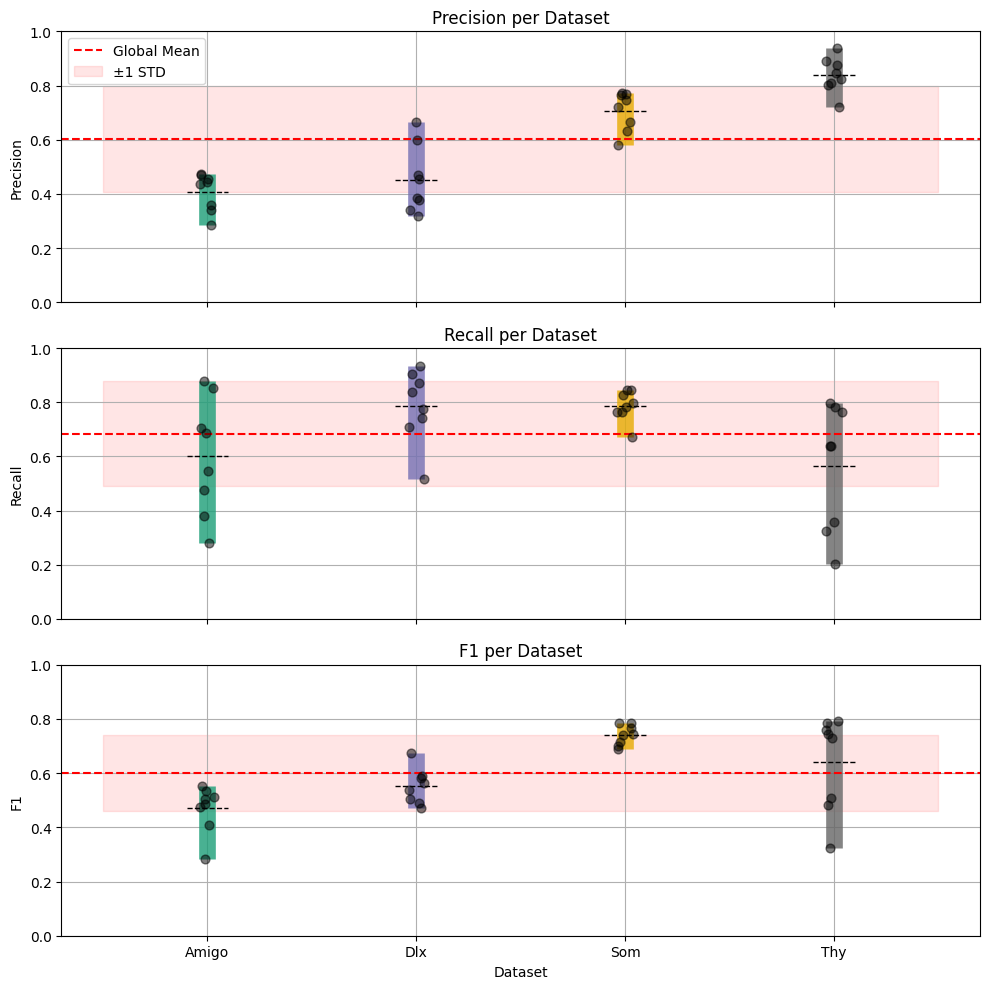

In [749]:
import matplotlib.pyplot as plt
import numpy as np

channel_ids = np.arange(8)
datasets = list(metrics_channels["precision"].keys())
n_datasets = len(datasets)
labels = ["Amigo", "Dlx", "Som", "Thy"]

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
colors=plt.cm.Dark2(np.linspace(0, 1, n_datasets))
# Plotting the metrics for each dataset
for idx, metric_name in enumerate(["precision", "recall", "f1"]):
    ax = axes[idx]
    metric_data = metrics_channels[metric_name]
    global_values = []

    for i, dataset in enumerate(datasets):
        values = metric_data[dataset]
        global_values.extend(values)
        xpos = i
        min_val = np.min(values)
        max_val = np.max(values)
        mean_val = np.mean(values)

 
           
       
        # Plot candle-style range per dataset (no drift!)
        ax.vlines(xpos, min_val, max_val, color=colors[i], lw=12, alpha=0.8)
        # Mean line (black, short horizontal line)
        mean_line_width = 0.2
        ax.hlines(mean_val, xpos - mean_line_width / 2, xpos + mean_line_width / 2,
                  color='black', linewidth=1,linestyle='--')
        # Apply jitter to x positions for scatter plot
        jitter_strength = 0.04
        jittered_x = xpos + np.random.uniform(-jitter_strength, jitter_strength, size=len(values))
        ax.scatter(jittered_x, values, color="black", alpha=0.5, s=40,zorder=3)
    
        

     
    # Global stats
    global_mean = np.mean(global_values)
    global_std = np.std(global_values)
    print(f"Global {metric_name} mean: {global_mean:.2f}, std: {global_std:.2f}")
    ax.axhline(global_mean, color='red', linestyle='--', label='Global Mean')
    ax.fill_between([-0.5, n_datasets - 0.5],
                    global_mean - global_std, global_mean + global_std,
                    color='red', alpha=0.1, label='±1 STD')

    # Formatting
    ax.set_ylabel(metric_name.capitalize())
    ax.set_title(f"{metric_name.capitalize()} per Dataset")
    ax.set_xticks(np.arange(n_datasets))
    ax.set_xticklabels(labels)
    ax.set_ylim(0, 1.0)
    ax.grid(True)
    if idx == 0:
        ax.legend()

plt.xlabel("Dataset")
plt.tight_layout()
plt.show()


In [750]:
from collections import Counter
def count_by_num_channels(sets_list_or_dict):
    """
    Input:
        - sets_list_or_dict: list or dict of sets (e.g., ripple_hits or fp_timing_to_channels)
    Output:
        - Counter mapping: number of channels → count of events with that many channels
    """
    if isinstance(sets_list_or_dict, dict):
        sets_iter = sets_list_or_dict.values()
    else:
        sets_iter = sets_list_or_dict

    counts = Counter()
    for ch_set in sets_iter:
        n = len(ch_set)
        counts[n] += 1
    return counts

# Add sharing stats to each dataset
for dataset in keys_minus_overall:
    info= information_dataset[dataset]
    ripple_hits = info["ripple_hits"]  # dict: ripple_index → set(channels)
    fp_timing_to_channels = info.get("fp_timing_to_channels", {})  # dict: time → set(channels)

    # Compute counts
    ripple_sharing_counts = count_by_num_channels(ripple_hits)
    fp_sharing_counts = count_by_num_channels(fp_timing_to_channels)

    # Store in original dataset info
    info["ripple_sharing_counts"] = ripple_sharing_counts
    info["fp_sharing_counts"] = fp_sharing_counts

    # Optional: print summary
    print(f"Dataset: {dataset}")
    print("Ripples shared across channels:")
    for channels_num in range(1, num_channels + 1):
        print(f"  Shared by {channels_num} channel(s): {ripple_sharing_counts.get(channels_num, 0)}")

    print("False positives shared across channels:")
    for channels_num in range(1, num_channels + 1):
        print(f"  Shared by {channels_num} channel(s): {fp_sharing_counts.get(channels_num, 0)}")


Dataset: Amigo2_2019-07-11_11-57-07
Ripples shared across channels:
  Shared by 1 channel(s): 19
  Shared by 2 channel(s): 19
  Shared by 3 channel(s): 26
  Shared by 4 channel(s): 24
  Shared by 5 channel(s): 24
  Shared by 6 channel(s): 31
  Shared by 7 channel(s): 20
  Shared by 8 channel(s): 50
False positives shared across channels:
  Shared by 1 channel(s): 280
  Shared by 2 channel(s): 131
  Shared by 3 channel(s): 84
  Shared by 4 channel(s): 55
  Shared by 5 channel(s): 49
  Shared by 6 channel(s): 30
  Shared by 7 channel(s): 10
  Shared by 8 channel(s): 15
Dataset: Dlx1_2021-02-12_12-46-54
Ripples shared across channels:
  Shared by 1 channel(s): 0
  Shared by 2 channel(s): 2
  Shared by 3 channel(s): 1
  Shared by 4 channel(s): 0
  Shared by 5 channel(s): 2
  Shared by 6 channel(s): 3
  Shared by 7 channel(s): 8
  Shared by 8 channel(s): 13
False positives shared across channels:
  Shared by 1 channel(s): 52
  Shared by 2 channel(s): 17
  Shared by 3 channel(s): 14
  Shared

In [751]:
#### Calculate metrics per dataset based on TP, FN, FP counts
metrics_per_dataset = []
keys= information_dataset.keys()
keys_minus_overall = [k for k in keys if k != "overall_metrics"]
for i, dataset_name in enumerate(keys_minus_overall):
    tp = tp_per_dataset[i]
    fn = fn_per_dataset[i]
    fp = fp_per_dataset[i]  
    # Calculate metrics
    tp_all = tp_all_dataset[i]
    fn_all = fn_all_dataset[i]
    fp_all = fp_all_dataset[i]

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    fdr = fp / (tp + fp) if (tp + fp) > 0 else 0.0

    precision_all = tp_all / (tp_all + fp_all) if (tp_all + fp_all) > 0 else 0.0
    recall_all = tp_all / (tp_all + fn_all) if (tp_all + fn_all) > 0 else 0.0
    f1_score_all = (2 * precision_all * recall_all) / (precision_all + recall_all) if (precision_all + recall_all) > 0 else 0.0
    metrics = {
        "dataset": dataset_name,
        "TP": tp,
        "FN": fn,
        "FP": fp,
        "Precision": precision,
        "Recall": recall,
        "F1": f1_score,
        "FDR": fdr,
        "TP_all": tp_all,
        "FN_all": fn_all,
        "FP_all": fp_all,
        "precision_all": precision_all,
        "recall_all": recall_all,
        "f1_score_all": f1_score_all,
    }

    metrics_per_dataset.append(metrics)
    information_dataset[dataset_name]["metrics"] = metrics  # save in original dict

# Optional: print summary
for m in metrics_per_dataset:
    print(f"{m['dataset']}: Precision={m['Precision']:.4f}, Recall={m['Recall']:.4f}, F1={m['F1']:.4f}, FDR={m['FDR']:.4f}")
    print(f"  TP={m['TP']}, FN={m['FN']}, FP={m['FP']}")
    



Amigo2_2019-07-11_11-57-07: Precision=0.4187, Recall=0.7812, F1=0.5452, FDR=0.5813
  TP=175, FN=49, FP=243
Dlx1_2021-02-12_12-46-54: Precision=0.3913, Recall=0.8710, F1=0.5400, FDR=0.6087
  TP=27, FN=4, FP=42
Som2_2019-07-24_12-01-49: Precision=0.6795, Recall=0.8281, F1=0.7465, FDR=0.3205
  TP=53, FN=11, FP=25
Thy7_2020-11-11_16-05-00: Precision=0.8571, Recall=0.7770, F1=0.8151, FDR=0.1429
  TP=108, FN=31, FP=18


In [752]:
for m in metrics_per_dataset:
    print(f"{m['dataset']}: TP_all={m['TP_all']}, FN_all={m['FN_all']}, FP_all={m['FP_all']}")
    print(f"Precision_all={m['precision_all']:.4f}, Recall_all={m['recall_all']:.4f}, F1_all={m['f1_score_all']:.4f}")



Amigo2_2019-07-11_11-57-07: TP_all=1077, FN_all=715, FP_all=1629
Precision_all=0.3980, Recall_all=0.6010, F1_all=0.4789
Dlx1_2021-02-12_12-46-54: TP_all=195, FN_all=53, FP_all=277
Precision_all=0.4131, Recall_all=0.7863, F1_all=0.5417
Som2_2019-07-24_12-01-49: TP_all=403, FN_all=109, FP_all=175
Precision_all=0.6972, Recall_all=0.7871, F1_all=0.7394
Thy7_2020-11-11_16-05-00: TP_all=627, FN_all=485, FP_all=138
Precision_all=0.8196, Recall_all=0.5638, F1_all=0.6681


In [753]:
print("Recall 3, Precision 1")
for m in metrics_per_dataset:
    # Calc F1
    f1= 2 * (m['precision_all'] * m['Recall']) / (m['precision_all'] + m['Recall']) if (m['precision_all'] + m['Recall']) > 0 else 0.0
    print(f"{m['dataset']}: Precision={m['precision_all']:.4f}, Recall={m['Recall']:.4f}, F1={f1:.4f}, FDR={m['FDR']:.4f}")


Recall 3, Precision 1
Amigo2_2019-07-11_11-57-07: Precision=0.3980, Recall=0.7812, F1=0.5274, FDR=0.5813
Dlx1_2021-02-12_12-46-54: Precision=0.4131, Recall=0.8710, F1=0.5604, FDR=0.6087
Som2_2019-07-24_12-01-49: Precision=0.6972, Recall=0.8281, F1=0.7571, FDR=0.3205
Thy7_2020-11-11_16-05-00: Precision=0.8196, Recall=0.7770, F1=0.7977, FDR=0.1429


In [754]:
# Total counts
total_tp = sum(tp_per_dataset)
total_fn = sum(fn_per_dataset)
total_fp = sum(fp_per_dataset)
total_tp_all = sum(tp_all_dataset)
total_fn_all = sum(fn_all_dataset)
total_fp_all = sum(fp_all_dataset)

# Overall metrics
overall_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
overall_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0
overall_f1 = (2 * overall_precision * overall_recall) / (overall_precision + overall_recall) if (overall_precision + overall_recall) > 0 else 0.0
overall_fdr = total_fp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0

# Overall metrics all
overall_precision_all = total_tp_all / (total_tp_all + total_fp_all) if (total_tp_all + total_fp_all) > 0 else 0.0
overall_recall_all = total_tp_all / (total_tp_all + total_fn_all) if (total_tp_all + total_fn_all) > 0 else 0.0
overall_f1_all = (2 * overall_precision_all * overall_recall_all) / (overall_precision_all + overall_recall_all) if (overall_precision_all + overall_recall_all) > 0 else 0.0

# Store in dict
overall_metrics = {
    "Total TP": total_tp,
    "Total FN": total_fn,
    "Total FP": total_fp,
    "Precision": overall_precision,
    "Recall": overall_recall,
    "F1 Score": overall_f1,
    "FDR": overall_fdr,
}
information_dataset["overall_metrics"] = overall_metrics
# Print nicely
print("\n--- Overall Metrics Across All Datasets ---")
for k, v in overall_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

print("\n--- Overall Metrics Across All Datasets (All) ---")
overall_metrics_all = {
    "Total TP_all": total_tp_all,
    "Total FN_all": total_fn_all,
    "Total FP_all": total_fp_all,
    "Precision_all": overall_precision_all,
    "Recall_all": overall_recall_all,
    "F1 Score_all": overall_f1_all,
}
for k, v in overall_metrics_all.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")
    


--- Overall Metrics Across All Datasets ---
Total TP: 363
Total FN: 95
Total FP: 328
Precision: 0.5253
Recall: 0.7926
F1 Score: 0.6319
FDR: 0.4747

--- Overall Metrics Across All Datasets (All) ---
Total TP_all: 2302
Total FN_all: 1362
Total FP_all: 2219
Precision_all: 0.5092
Recall_all: 0.6283
F1 Score_all: 0.5625


In [739]:
# import pickle
# path=os.path.join(os.getcwd(), "information_dataset_channels")
# os.makedirs(path, exist_ok=True)
# file_name=f"{prefix}_information_dataset.pkl" if not SEEDED else f"{prefix}_information_dataset_seed{seed}.pkl"
# with open(os.path.join(path,file_name), "wb") as f:
#     pickle.dump(information_dataset, f)

In [740]:
datasets= list(information_dataset.keys())
# Remove "overall metrics"
if "overall_metrics" in datasets:
    datasets.remove("overall_metrics")

# Consider mean_detection_offset
offset=31

latency_data = []
mean_latencies = []

# Collect latencies
for dataset in datasets:
    latencies = information_dataset[dataset]["latencies"]
    # latencies = [lat - offset for lat in latencies if lat-offset>=0]  # Adjust latencies by offset and filter out negatives
    latency_data.append(latencies)
    mean_latency= np.mean(latencies) if latencies else 0.0
    mean_latencies.append(mean_latency)
    print(f"Dataset: {dataset}, Mean Latency: {mean_latency:.2f} ms")

# Compute overall average latency
all_latencies = [lat for sublist in latency_data for lat in sublist]
overall_avg_latency = np.mean(all_latencies)


print(f"Overall average latency across all datasets: {overall_avg_latency:.2f} ms")

Dataset: Amigo2_2019-07-11_11-57-07, Mean Latency: 36.23 ms
Dataset: Dlx1_2021-02-12_12-46-54, Mean Latency: 34.97 ms
Dataset: Som2_2019-07-24_12-01-49, Mean Latency: 30.49 ms
Dataset: Thy7_2020-11-11_16-05-00, Mean Latency: 42.97 ms
Overall average latency across all datasets: 37.02 ms


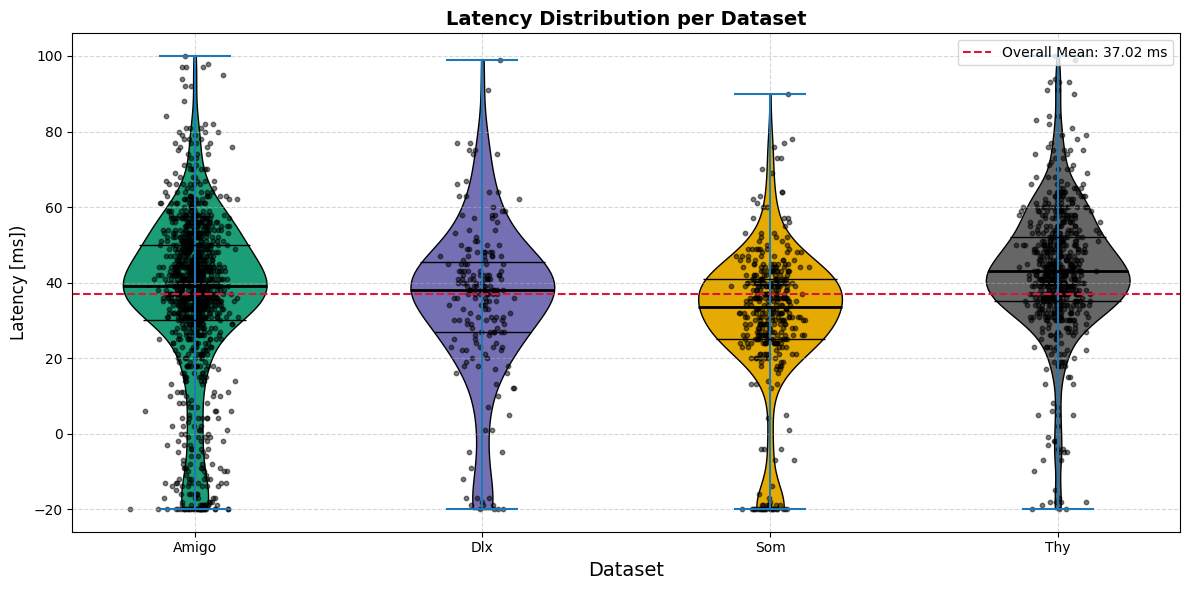

In [741]:
import matplotlib.pyplot as plt
import numpy as np


# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 6))


# Create violin plot
# quantiles = [[0.25, 0.5, 0.75]] * len(latency_data)
parts = ax.violinplot(latency_data, showmeans=False, showmedians=False, showextrema=True)

# Style violins
for i,pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_edgecolor('black')
    pc.set_alpha(1)

# Style median lines
if 'cmedians' in parts:
    parts['cmedians'].set_color('darkorange')
    parts['cmedians'].set_linewidth(2)

# Plot overall mean line
ax.axhline(overall_avg_latency, color='crimson', linestyle='--', linewidth=1.5,
           label=f'Overall Mean: {overall_avg_latency:.2f} ms')

for i, (latencies, body) in enumerate(zip(latency_data, parts['bodies'])):
    q25 = np.percentile(latencies, 25)
    q75 = np.percentile(latencies, 75)
    q50= np.percentile(latencies, 50)
    # Get all (x, y) coordinates from the violin shape
    verts = body.get_paths()[0].vertices
    xs, ys = verts[:, 0], verts[:, 1]

    # Get left and right x for 25th percentile
    x_q25 = xs[np.isclose(ys, q25, atol=1)]  # Adjust `atol` for sensitivity
    if len(x_q25) >= 2:
        x25_left, x25_right = np.min(x_q25), np.max(x_q25)
        ax.hlines(q25, x25_left, x25_right, color='black', linestyle='-', linewidth=1,
                  label='25th Percentile' if i == 10 else '_nolegend_')

    # Get left and right x for 75th percentile
    x_q75 = xs[np.isclose(ys, q75, atol=1)]
    if len(x_q75) >= 2:
        x75_left, x75_right = np.min(x_q75), np.max(x_q75)
        ax.hlines(q75, x75_left, x75_right, color='black', linestyle='-', linewidth=1,
                  label='75th Percentile' if i == 10 else '_nolegend_')
        
    # Get left and right x for 75th percentile
    x_q50 = xs[np.isclose(ys, q50, atol=1)]
    if len(x_q50) >= 2:
        x50_left, x50_right = np.min(x_q50), np.max(x_q50)
        ax.hlines(q50, x50_left, x50_right, color='black', linestyle='-', linewidth=2,
                  label='Median' if i == 10 else '_nolegend_')

    
# Overlay individual data points
positions = np.arange(1, len(datasets) + 1)
for i, latencies in enumerate(latency_data):
    jitter = np.random.normal(loc=0, scale=0.05, size=len(latencies))  # Add horizontal jitter
    ax.scatter(np.full(len(latencies), positions[i]) + jitter, latencies,
               color='black', s=10, alpha=0.5, label='_nolegend_')
    
# Plot per-dataset means (green dots)
# positions = np.arange(1, len(datasets) + 1)
# for i, mean in enumerate(mean_latencies):
#     ax.plot(positions[i], mean, 'go')
#     ax.text(positions[i], mean + 1, f'{mean:.1f}', ha='center', va='bottom', fontsize=9, color='green')

# Labeling and Styling
ax.set_title("Latency Distribution per Dataset", fontsize=14, weight='bold')
ax.set_ylabel("Latency [ms])", fontsize=12)
ax.set_xlabel("Dataset", fontsize=14)
ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=0)
ax.legend(loc='upper right', frameon=True)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()